In [1]:
import requests
import pandas as pd

In [ ]:
url = "https://www.deribit.com/api/v2/public/get_instruments"

params = {
    "currency": "BTC",
    "kind": "option"
}

response = requests.get(url, params=params)

data = response.json()["result"]

url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"

params = {
    "currency": "BTC",
    "kind": "option"
}

options = requests.get(
    url,
    params=params
).json()["result"]

for x in options[:3]:
    print(x)
    print(
        x["instrument_name"],
        x["mark_iv"],
        x["underlying_price"]
    )

target_expiry = "25DEC26"

options = [
    x for x in options
    if target_expiry in x["instrument_name"] and x["open_interest"] >= 10
]

print(options)

curve = []

for option in options:
    print('yes', option)

    strike = int(option["instrument_name"].split("-")[2])
    print('strike: ', strike)
    curve.append({
        "strike": strike,
        "iv": option["mark_iv"],
    })

curve.sort(key=lambda x: x["strike"])

{'high': None, 'low': None, 'last': 0.6906, 'instrument_name': 'BTC-28AUG26-110000-P', 'interest_rate': 0.0, 'bid_price': 0.698, 'ask_price': 0.722, 'open_interest': 0.2, 'mark_price': 0.71447091, 'creation_timestamp': 1785860043373, 'price_change': None, 'volume': 0.0, 'mark_iv': 65.75, 'underlying_price': 64160.23, 'underlying_index': 'BTC-28AUG26', 'base_currency': 'BTC', 'quote_currency': 'BTC', 'estimated_delivery_price': 63970.77, 'volume_usd': 0.0, 'mid_price': 0.71}
BTC-28AUG26-110000-P 65.75 64160.23
{'high': None, 'low': None, 'last': 0.402, 'instrument_name': 'BTC-25DEC26-40000-C', 'interest_rate': 0.0, 'bid_price': 0.394, 'ask_price': 0.3975, 'open_interest': 250.9, 'mark_price': 0.39593281, 'creation_timestamp': 1785860043373, 'price_change': None, 'volume': 0.0, 'mark_iv': 56.47, 'underlying_price': 65080.06, 'underlying_index': 'BTC-25DEC26', 'base_currency': 'BTC', 'quote_currency': 'BTC', 'estimated_delivery_price': 63970.77, 'volume_usd': 0.0, 'mid_price': 0.39575}
BT

In [ ]:
class BTCOptionSurface:

    def get_smile(self, expiry):
        target_expiry = "25DEC26"

        options = [
            x for x in options
            if target_expiry in x["instrument_name"] and x["open_interest"] >= 10
        ]

        print(options)

        self.curve = []

        for option in options:
            print('yes', option)

            strike = int(option["instrument_name"].split("-")[2])
            print('strike: ', strike)
            self.curve.append({
                "strike": strike,
                "iv": option["mark_iv"],
            })

        self.curve.sort(key=lambda x: x["strike"])

        return self.curve


    def interpolate_iv(strike):
        ...

    def probability_finish_above(strike):
        ...

    def probability_hit_before_expiry(strike):
        ...

In [ ]:
class Deribit:

    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.deribit.com/api/v2/public/get_index_price"
        params = {"index_name": "btc_usd"}

        self.spot = requests.get(url, params=params).json()["result"]["index_price"]
        print("spot:", self.spot)

    def get_df(self):
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        deribit_instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        deribit_quotes_df = pd.DataFrame(quotes)

        self.deribit_df = deribit_instruments_df.merge(deribit_quotes_df, on="instrument_name", how="left")
        self.deribit_df

    def get_smile(self, target_expiry):

        self.options_df = self.deribit_df[
            (self.deribit_df["instrument_name"].str.split("-").str.get(1) == target_expiry) &
            (self.deribit_df["option_type"] == "call") &
            (self.deribit_df["open_interest"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

target_expiry = "25DEC26"
dr = Deribit(target_expiry=target_expiry)
dr.options_df

spot: 64053.06


,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,price_change,volume,mark_iv,underlying_price,underlying_index,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price
538,open,btc_usd,option,BTC-25DEC26-30000-C,reversed,0.0003,0.0003,crypto,587781,1798185600000,...,0.0000,1.6,69.86,65146.48,BTC-25DEC26,BTC,BTC,64051.38,55616.06,0.54425
540,open,btc_usd,option,BTC-25DEC26-35000-C,reversed,0.0003,0.0003,crypto,573922,1798185600000,...,NaN,0.0,62.61,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.46975
542,open,btc_usd,option,BTC-25DEC26-40000-C,reversed,0.0003,0.0003,crypto,568999,1798185600000,...,NaN,0.0,56.64,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.39625
544,open,btc_usd,option,BTC-25DEC26-45000-C,reversed,0.0003,0.0003,crypto,573924,1798185600000,...,NaN,0.0,51.01,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.32475
546,open,btc_usd,option,BTC-25DEC26-50000-C,reversed,0.0003,0.0003,crypto,569001,1798185600000,...,NaN,0.0,46.41,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.25725
550,open,btc_usd,option,BTC-25DEC26-54000-C,reversed,0.0003,0.0003,crypto,593343,1798185600000,...,NaN,0.0,43.62,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.20725
552,open,btc_usd,option,BTC-25DEC26-55000-C,reversed,0.0003,0.0003,crypto,573926,1798185600000,...,NaN,0.0,43.05,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.19525
554,open,btc_usd,option,BTC-25DEC26-56000-C,reversed,0.0003,0.0003,crypto,592708,1798185600000,...,NaN,0.0,42.53,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.18375
556,open,btc_usd,option,BTC-25DEC26-58000-C,reversed,0.0003,0.0003,crypto,590445,1798185600000,...,NaN,0.0,41.61,65146.48,BTC-25DEC26,BTC,BTC,64051.38,0.00,0.16225
558,open,btc_usd,option,BTC-25DEC26-60000-C,reversed,0.0003,0.0003,crypto,567079,1798185600000,...,0.0000,0.5,40.79,65146.48,BTC-25DEC26,BTC,BTC,64051.38,4593.38,0.14200


In [49]:
dr.options_df.columns

Index(['state', 'price_index', 'kind', 'instrument_name', 'instrument_type',
       'maker_commission', 'taker_commission', 'underlying_type',
       'instrument_id', 'expiration_timestamp', 'is_active',
       'creation_timestamp_x', 'tick_size', 'contract_size', 'strike',
       'base_currency_x', 'quote_currency_x', 'settlement_currency',
       'option_type', 'min_trade_amount', 'block_trade_commission',
       'block_trade_min_trade_amount', 'block_trade_tick_size',
       'settlement_period', 'counter_currency', 'lot_size', 'tick_size_steps',
       'base_currency_uuid', 'quote_currency_uuid', 'high', 'low', 'last',
       'interest_rate', 'bid_price', 'ask_price', 'open_interest',
       'mark_price', 'creation_timestamp_y', 'price_change', 'volume',
       'mark_iv', 'underlying_price', 'underlying_index', 'base_currency_y',
       'quote_currency_y', 'estimated_delivery_price', 'volume_usd',
       'mid_price'],
      dtype='str')

In [16]:
url = "https://api.bybit.com/v5/market/tickers"
params = {
    "baseCoin": "BTC",
    "category": "option"
}

bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
bybit_df = pd.DataFrame(bybit_data)

bybit_df

,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,turnover24h,volume24h,totalVolume,totalTurnover,delta,gamma,vega,theta,predictedDeliveryPrice,change24h
0,BTC-25JUN27-70000-C-USDT,8820,9.44,0.4084,9180,8.83,0.4228,8465,8465,8465,...,0,0,1,31949,0.52775716,0.00001522,249.99047749,-16.02670583,0,0
1,BTC-25JUN27-120000-C-USDT,880,17.51,0.4031,1150,26.78,0.4284,600,600,600,...,0,0,1,6687,0.09410138,0.00000647,105.42836745,-6.70902379,0,0
2,BTC-25JUN27-98000-P-USDT,32845,18.55,0.3414,34810,18.55,0.454,0,0,0,...,0,0,0,0,-0.79439913,0.00001121,178.78527056,-11.13612699,0,0
3,BTC-25JUN27-120000-P-USDT,53570,18.55,0.3008,55160,18.55,0.4768,0,0,0,...,0,0,0,0,-0.90589863,0.00000647,105.42836745,-6.70902379,0,0
4,BTC-25JUN27-130000-C-USDT,580,19.09,0.4069,860,37.6,0.44,910,910,910,...,0,0,1,7334,0.06737013,0.00000496,81.88666797,-5.2817218,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,BTC-25DEC26-95000-P-USDT,30090,18.55,0.3405,30580,18.55,0.4271,28395,28395,28395,...,0,0,1,34287,-0.92280025,0.00000911,58.95241398,-8.05810886,0,0
568,BTC-25DEC26-90000-P-USDT,25340,2,0.3483,25830,2,0.4133,25000,25000,25000,...,0,0,5,334925,-0.88967458,0.00001205,76.76762397,-10.33295941,0,0
569,BTC-25DEC26-60000-C-USDT,9030,3,0.3921,9545,3,0.4272,9100,9200,9100,...,1300.5391,0.02,6,360444,0.6737851,0.00002158,146.85187363,-21.10585424,0,-0.01247966
570,BTC-25DEC26-90000-C-USDT,740,12.2,0.3818,765,12.2,0.3851,755,755,655,...,144216.9477,2.22,49,3207897,0.11032543,0.00001205,76.76762397,-10.33295941,0,0.15267176


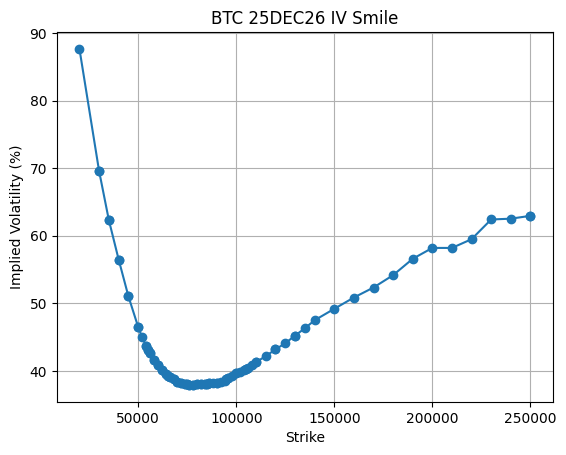

In [3]:
import matplotlib.pyplot as plt

strikes = [x["strike"] for x in curve]
ivs = [x["iv"] for x in curve]

plt.plot(strikes, ivs, marker="o")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title("BTC 25DEC26 IV Smile")
plt.grid(True)

plt.show()

In [28]:
from scipy.interpolate import interp1d

# Question: Will BTC hit 100000?

required_strike = 100000

strikes = [x["strike"] for x in curve]
ivs = [x["iv"] for x in curve]

f = interp1d(
    strikes,
    ivs,
    kind="linear",
    fill_value="extrapolate"
)

iv = float(f(required_strike)) / 100

print(f'{required_strike} strike iv: {iv}')

100000 strike iv: 0.3996


In [ ]:
from scipy.stats import norm
import numpy as np

def prob_finish_above(
    spot,
    strike,
    iv,
    T,
    r=0
):

    sigma = iv / 100

    d2 = (
        np.log(spot/strike)
        + (r - 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return norm.cdf(d2)


from datetime import datetime, timezone

today = datetime.now(timezone.utc)
expiry = datetime(2026, 12, 25, tzinfo=timezone.utc)

spot = 64434

T = (expiry - today).days / 365

p = prob_finish_above(
    spot=spot,
    strike=required_strike,
    iv=iv,
    T=T,
    r=0
)

print(p)

0.030282300001032627


In [29]:
def prob_touch(
    spot,
    strike,
    iv,
    T,
    r=0,
    paths=100000
):
    steps = 365
    # paths = 100000

    Z = np.random.normal(
        0,
        1,
        size=(paths, steps)
    )

    dt = T / steps

    daily_return = (
        (r - 0.5*iv**2)*dt
        + iv*np.sqrt(dt)*Z
    )

    prices = spot * np.exp(
        np.cumsum(daily_return, axis=1)
    )

    hit = prices.max(axis=1) >= strike

    p_touch = hit.mean()

    print(p_touch)

p = prob_touch(
    spot=spot,
    strike=required_strike,
    iv=iv,
    T=T,
    r=0
)

for paths in [10000, 50000, 100000, 500000]:
        prob_touch(
        spot=spot,
        strike=required_strike,
        iv=iv,
        T=T,
        r=0,
        paths=paths
    )

0.05882
0.0641
0.05888
0.05843
0.059654


In [ ]:
class BTCOptionSurface:

    def get_smile(expiry):
        ...

    def interpolate_iv(strike):
        ...

    def probability_finish_above(strike):
        ...

    def probability_hit_before_expiry(strike):
        ...

In [5]:
print(len(options))

118


[{'strike': 25000.0, 'iv': 76.02860407658008}, {'strike': 30000.0, 'iv': 67.97588487726141}, {'strike': 35000.0, 'iv': 60.81152231115708}, {'strike': 40000.0, 'iv': 54.718802285264786}, {'strike': 45000.0, 'iv': 49.745798044220976}, {'strike': 50000.0, 'iv': 45.849852553247544}, {'strike': 52000.0, 'iv': 44.57258452914943}, {'strike': 55000.0, 'iv': 42.93462085447431}, {'strike': 58000.0, 'iv': 41.605781653749844}, {'strike': 60000.0, 'iv': 40.87773191937083}, {'strike': 62000.0, 'iv': 40.26623139583852}, {'strike': 65000.0, 'iv': 39.54963991804855}, {'strike': 68000.0, 'iv': 39.04375183252493}, {'strike': 70000.0, 'iv': 38.798976452484915}, {'strike': 72000.0, 'iv': 38.62015727370661}, {'strike': 75000.0, 'iv': 38.46372926145182}, {'strike': 80000.0, 'iv': 38.46009806303175}, {'strike': 85000.0, 'iv': 38.71912280051353}, {'strike': 90000.0, 'iv': 39.18327355698579}, {'strike': 95000.0, 'iv': 39.805064707348954}, {'strike': 100000.0, 'iv': 40.545638184141005}, {'strike': 105000.0, 'iv'

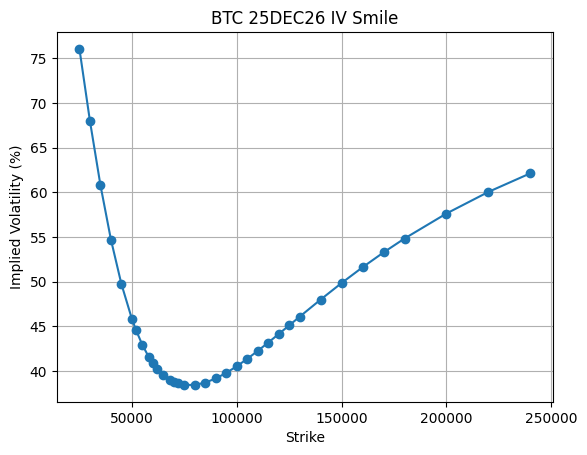

In [7]:
import requests

expiry = "BTC-USD-261225"

data = requests.get(
    "https://www.okx.com/api/v5/public/opt-summary",
    params={"uly": "BTC-USD"}
).json()["data"]

curve = []

for o in data:
    if (
        o["instId"].startswith(expiry)
        and o["instId"].endswith("-C")
    ):
        strike = float(o["instId"].split("-")[3])

        curve.append({
            "strike": strike,
            "iv": float(o["markVol"]) * 100
        })

curve.sort(key=lambda x: x["strike"])

print(curve)

import matplotlib.pyplot as plt

strikes = [x["strike"] for x in curve]
ivs = [x["iv"] for x in curve]

plt.plot(strikes, ivs, marker="o")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title("BTC 25DEC26 IV Smile")
plt.grid(True)

plt.show()

In [ ]:
class OKX:

    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": "BTC-USDT"}

        self.spot = float(requests.get(url=url, params=params).json()["data"][0]["last"])
        print("spot:", self.spot)

    def get_df(self):

        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": "BTC-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": "BTC-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["expiry"] = parts.str[2]
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})

        self.okx_df = summary_df.merge(oi_df, on="instId", how="left")

    def get_smile(self, target_expiry):

        self.options_df = self.okx_df[
            (self.okx_df["ccy"] == "USD") &
            (self.okx_df["expiry"] == target_expiry) &
            (self.okx_df["option_type"] == "call") &
            (self.okx_df["open_interest"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

target_expiry = "261225"
okx = OKX(target_expiry=target_expiry)
okx.options_df

spot: 64135.6


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,volLv,ccy,strike,expiry,option_type,instType_y,open_interest,oiCcy,oiUsd,ts_y
575,0.7550133728027344,0.6713953759765626,,0.4337325651288455,0.9767791237592057,-0.53985434,65196.74592435861624,-0.7470630003739017,0.0000018788876976197413,BTC-USD-261225-30000-C,...,0.3886549969893326,USD,30000.0,261225,call,OPTION,4075.0,40.75,2611606.375,1785903273827
568,0.669564324951172,0.6134120935058593,,0.49455002516482643,0.9632121835595611,-0.46316339,65196.74592435861624,-0.7874027307198882,0.0000031475075467804265,BTC-USD-261225-35000-C,...,0.3886549969893326,USD,35000.0,261225,call,OPTION,150.0,1.5,96132.75,1785903273827
552,0.5279630456542967,0.4992765795898437,,0.584175887139054,0.9084433463039542,-0.3097815,65196.74592435861624,-0.650326283509614,0.000008083841395478486,BTC-USD-261225-45000-C,...,0.3886549969893326,USD,45000.0,261225,call,OPTION,163.0,1.63,104464.255,1785903273827
549,0.476388441772461,0.4550261798095704,,0.5988531864939087,0.8556303383869082,-0.23309056,65196.74592435861624,-0.4135018706198695,0.000012237592419164753,BTC-USD-261225-50000-C,...,0.3886549969893326,USD,50000.0,261225,call,OPTION,510.0,5.1,326851.35,1785903273827
576,0.4608245080566406,0.4422088226318359,,0.5964129187855013,0.8276931686058531,-0.20241418,65196.74592435861624,-0.2837752226005263,0.000014185828927031727,BTC-USD-261225-52000-C,...,0.3886549969893326,USD,52000.0,261225,call,OPTION,50.0,0.5,32044.25,1785903273827
556,0.43946224609375,0.42328796203613284,,0.5825875688067369,0.7777265385510784,-0.15639961,65196.74592435861624,-0.059071978434826346,0.000017260854272968328,BTC-USD-261225-55000-C,...,0.3886549969893326,USD,55000.0,261225,call,OPTION,680.0,6.8,435801.8,1785903273827
629,0.42221984893798825,0.41031801727294925,,0.5562753130286413,0.7182805984404731,-0.11038505,65196.74592435861624,0.18619640724842398,0.000020267081866022483,BTC-USD-261225-58000-C,...,0.3886549969893326,USD,58000.0,261225,call,OPTION,253.0,2.53,162143.905,1785903273827
554,0.4124542434692383,0.4034515759277344,,0.5321887759827834,0.6740151312565876,-0.07970867,65196.74592435861624,0.3495491579653975,0.000022064472640055244,BTC-USD-261225-60000-C,...,0.3886549969893326,USD,60000.0,261225,call,OPTION,1009.0,10.09,646652.965,1785903273827
645,0.4034515759277344,0.3993317111206054,,0.5035545896595164,0.6268584620967254,-0.04903229,65196.74592435861624,0.5037349999492675,0.00002357687977934852,BTC-USD-261225-62000-C,...,0.3886549969893326,USD,62000.0,261225,call,OPTION,901.0,9.01,577437.385,1785903273827
562,0.3958221966552734,0.3917023318481445,,0.4540365138188572,0.5527974496635151,-0.00301773,65196.74592435861624,0.7022235116063485,0.000025128844149398004,BTC-USD-261225-65000-C,...,0.3886549969893326,USD,65000.0,261225,call,OPTION,13657.0,136.57,8752566.445,1785903273827


In [ ]:
class Bybit:

    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": "BTCUSDT"
        }

        self.spot = float(requests.get(url=url, params=params).json()["result"]["list"][0]["lastPrice"])
        print("spot:", self.spot)

    def get_df(self):

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": "BTC",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        bybit_df = pd.DataFrame(bybit_data)
        bybit_df = bybit_df.rename(columns={"markIv": "mark_iv", 
                                            "openInterest": "open_interest"})

        bybit_df["open_interest"] = bybit_df["open_interest"].astype(float)
        parts = bybit_df["symbol"].str.split("-")
        bybit_df["expiry"] = parts.str[1]
        bybit_df["strike"] = parts.str[2].astype(float)
        bybit_df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})

        self.bybit_df = bybit_df

    def get_smile(self, target_expiry):

        self.options_df = self.bybit_df[
            (self.bybit_df["expiry"] == target_expiry) &
            (self.bybit_df["option_type"] == "call") &
            (self.bybit_df["open_interest"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

target_expiry = "25DEC26"
bybit = Bybit(target_expiry=target_expiry)
bybit.options_df

spot: 64156.5


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,totalTurnover,delta,gamma,vega,theta,predictedDeliveryPrice,change24h,expiry,strike,option_type
0,BTC-5AUG26-62250-C-USDT,1860,2,0,1960,2.4,1.0704,1890,2055,1320,...,837234,0.99994569,0.00000007,0.0028518,-0.05594023,0,0.18495298,5AUG26,62250.0,call
1,BTC-5AUG26-68000-P-USDT,3795,2,0,3890,2,1.7966,0,0,0,...,0,-1,0.00000001,0.00000022,-0.00000535,0,0,5AUG26,68000.0,put
2,BTC-5AUG26-64250-P-USDT,165,2.75,0.2269,185,0.48,0.2676,195,805,80,...,16172542,-0.60746406,0.0001754,4.91953713,-61.16850658,0,-0.71942447,5AUG26,64250.0,put
3,BTC-5AUG26-61500-P-USDT,0,0,0,5,30.06,0.944,5,25,5,...,18202192,-0.00000185,0.00000001,0.00011376,-0.00261345,0,-0.8,5AUG26,61500.0,put
4,BTC-5AUG26-62750-C-USDT,1360,2,0,1445,2.4,0.7734,1625,1625,870,...,1933533,0.99934748,0.00000075,0.02909219,-0.50542308,0,0.3,5AUG26,62750.0,call
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,BTC-8AUG26-63000-P-USDT,0,0,0,0,0,0,0,0,0,...,0,-0.24853657,0.00017457,18.87774573,-91.38641567,0,0,8AUG26,63000.0,put
606,BTC-8AUG26-64250-P-USDT,0,0,0,0,0,0,0,0,0,...,0,-0.50773798,0.00023749,23.76907814,-106.49490466,0,0,8AUG26,64250.0,put
607,BTC-8AUG26-63750-P-USDT,0,0,0,0,0,0,0,0,0,...,0,-0.39224843,0.00022361,22.90104286,-104.99648846,0,0,8AUG26,63750.0,put
608,BTC-8AUG26-63500-C-USDT,0,0,0,0,0,0,0,0,0,...,0,0.66056758,0.0002097,21.82094723,-101.65200386,0,0,8AUG26,63500.0,call


In [7]:
bybit.bybit_df.columns

Index(['symbol', 'bid1Price', 'bid1Size', 'bid1Iv', 'ask1Price', 'ask1Size',
       'ask1Iv', 'lastPrice', 'highPrice24h', 'lowPrice24h', 'markPrice',
       'indexPrice', 'mark_iv', 'underlyingPrice', 'open_interest',
       'turnover24h', 'volume24h', 'totalVolume', 'totalTurnover', 'delta',
       'gamma', 'vega', 'theta', 'predictedDeliveryPrice', 'change24h',
       'expiry', 'strike', 'option_type'],
      dtype='str')

In [11]:
bybit.bybit_df.iloc[0]["open_interest"]

'0.12'

{'symbol': 'BTC-25DEC26-250000-C-USDT', 'bid1Price': '10', 'bid1Size': '0.24', 'bid1Iv': '0.6758', 'ask1Price': '30', 'ask1Size': '3.47', 'ask1Iv': '0.7413', 'lastPrice': '10', 'highPrice24h': '30', 'lowPrice24h': '10', 'markPrice': '0.67318168', 'indexPrice': '63141.88002294', 'markIv': '0.5642', 'underlyingPrice': '64196.2', 'openInterest': '15.52', 'turnover24h': '1283.4021', 'volume24h': '0.02', 'totalVolume': '25', 'totalTurnover': '1700379', 'delta': '0.00013144', 'gamma': '0.00000003', 'vega': '0.20680786', 'theta': '-0.0403085', 'predictedDeliveryPrice': '0', 'change24h': '0'}
{'symbol': 'BTC-25DEC26-62000-C-USDT', 'bid1Price': '7480', 'bid1Size': '1.53', 'bid1Iv': '0.3998', 'ask1Price': '7605', 'ask1Size': '0.01', 'ask1Iv': '0.4079', 'lastPrice': '9115', 'highPrice24h': '9115', 'lowPrice24h': '9115', 'markPrice': '7571.38742296', 'indexPrice': '63141.88002294', 'markIv': '0.4058', 'underlyingPrice': '64196.2', 'openInterest': '1.72', 'turnover24h': '0', 'volume24h': '0', 'tota

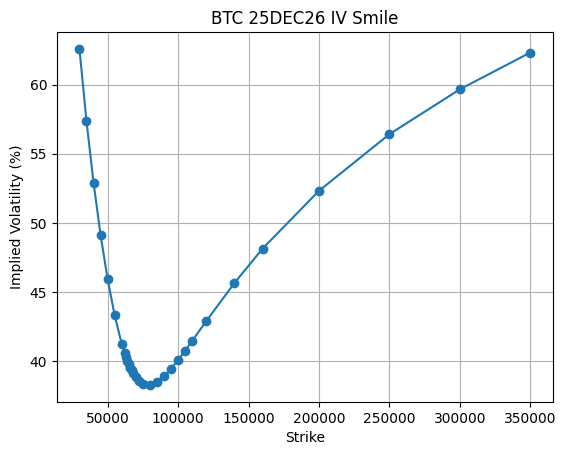

In [18]:
import requests

tickers = requests.get(
    "https://api.bybit.com/v5/market/tickers",
    params={
        "category": "option",
        "baseCoin": "BTC"
    }
).json()["result"]["list"]

curve = []
expiry = "25DEC26"

for t in tickers:
    
    if (
        t["symbol"].startswith(f"BTC-{expiry}")
        and t["symbol"].endswith("-C-USDT")
        and t.get("markIv") is not None
    ):
        print(t)
        curve.append({
            "strike": float(t["symbol"].split("-")[2]),
            "iv": float(t["markIv"]) * 100
        })

curve.sort(key=lambda x: x["strike"])

print(curve)

import matplotlib.pyplot as plt

strikes = [x["strike"] for x in curve]
ivs = [x["iv"] for x in curve]

plt.plot(strikes, ivs, marker="o")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title("BTC 25DEC26 IV Smile")
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import requests

tickers = requests.get(
    "https://api.bybit.com/v5/market/tickers",
    params={
        "category": "option",
        "baseCoin": "BTC"
    }
).json()["result"]["list"]

df = pd.DataFrame(tickers)

df.iloc[0].openInterest

'94.58'

In [ ]:
import pandas as pd

df = pd.DataFrame([
    {
        "exchange":"deribit",
        "strike":90000,
        "iv":0.72,
        "expiry":"2026-12-31"
    },
    {
        "exchange":"bybit",
        "strike":90000,
        "iv":0.70,
        "expiry":"2026-12-31"
    },
])

curve = (
    df
    .groupby("strike")
    .apply(
        lambda x:
        np.average(
            x.iv,
            weights=x.open_interest
        )
    )
)

In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.